In [116]:
import numpy as np
from mpi4py import MPI
import ufl
from dolfinx import fem, mesh, io, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from ufl import dx, grad, dot
import pyvista
from petsc4py import PETSc
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


In [117]:
# Crear Malla
nx, ny = 100, 100
dominio = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, mesh.CellType.triangle)

# Definir el espacio de funciones
espacio_funciones = fem.functionspace(dominio, ("Lagrange", 1))

/var/folders/8x/2_xy04_n0gs51pp95f6ltysh0000gn/T/ipykernel_28560/565386011.py:10: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


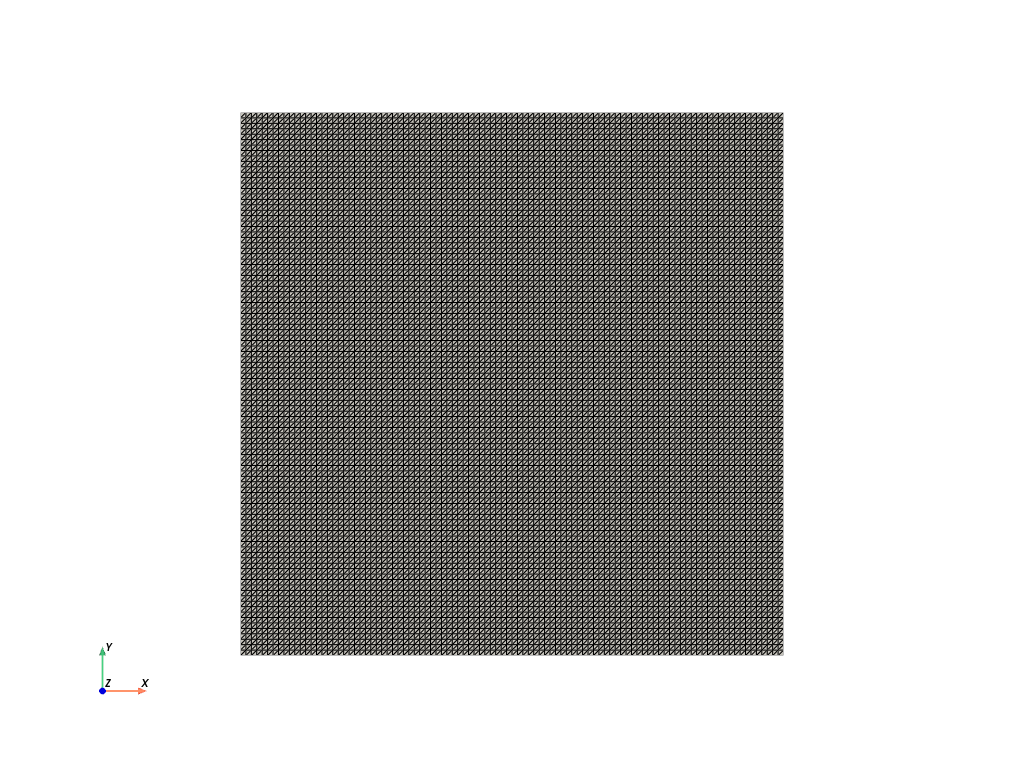

In [118]:
# Visualizar la malla
topology, cell_types, geometry = plot.vtk_mesh(dominio)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True, color="white")
plotter.view_xy()        
plotter.enable_parallel_projection()  
plotter.show_axes()
plotter.show()

In [119]:
# Parámetros
k_val = 1.0      
lambda_val = 1.0  
dt = 0.001        
T_final = 0.5  

k = fem.Constant(dominio, default_scalar_type(k_val))
lambd = fem.Constant(dominio, default_scalar_type(lambda_val))

In [120]:
# Funciones para trabajar
u_previo = fem.Function(espacio_funciones, name="u_previo")  
u_actual = fem.Function(espacio_funciones, name="u_actual")
v_actual = fem.Function(espacio_funciones, name="v_actual")    

# Definimos una condición inicial para u 
def funcion_inicial(x):
    return 10.0 * np.exp(-5.0 * ((x[0] - 0.75)**2 + (x[1] - 0.75)**2)) + 20.0 * np.exp(-50.0 * ((x[0] - 0.25)**2 + (x[1] - 0.25)**2))

# Interpolar en malla
u_previo.interpolate(funcion_inicial)
u_previo.x.scatter_forward()

In [121]:
# Funciones para forma débil
u = ufl.TrialFunction(espacio_funciones)
chi = ufl.TestFunction(espacio_funciones)
v = ufl.TrialFunction(espacio_funciones)
psi = ufl.TestFunction(espacio_funciones)


El problema auxiliar tiene la forma $(\nabla v, \nabla \psi) + (v, \psi) = (u_n, \psi)$.

In [122]:
# Operadores problema auxiliar
a_aux = ufl.dot(ufl.grad(v), ufl.grad(psi)) * ufl.dx + v * psi * ufl.dx
L_aux = u_previo * psi * ufl.dx
aux_bilineal = fem.form(a_aux)
aux_lineal = fem.form(L_aux)

# La matriz no cambia, se ensambla fuera del flujo
A_aux = fem.petsc.assemble_matrix(aux_bilineal)
A_aux.assemble()
b_aux = fem.petsc.create_vector(espacio_funciones)

# Resolver el problema auxiliar
solver_aux = PETSc.KSP().create(dominio.comm)
solver_aux.setOperators(A_aux)
solver_aux.setType(PETSc.KSP.Type.PREONLY)
solver_aux.getPC().setType(PETSc.PC.Type.LU)

Problema central tiene forma débil $( \frac{u - u_n}{dt} , \chi ) + ( k \nabla u , \nabla \chi ) - ( \lambda u \nabla v_n , \nabla \chi ) = 0$

In [123]:
# Operadores problema central
a_u = (u / dt) * chi * ufl.dx + k * ufl.dot(ufl.grad(u), ufl.grad(chi)) * ufl.dx - lambd * u * ufl.dot(ufl.grad(v_actual), ufl.grad(chi)) * ufl.dx
L_u = (u_previo / dt) * chi * ufl.dx
b_u = fem.petsc.create_vector(espacio_funciones)

# Resolver el problema central
solver_u = PETSc.KSP().create(dominio.comm)
solver_u.setType(PETSc.KSP.Type.BCGS)
solver_u.getPC().setType(PETSc.PC.Type.ILU)

In [124]:
def u_exacta_func(x, t):
    sigma_sq = 0.02 + 2.0 * k_val * t
    return (10.0 * 0.02 / sigma_sq) * np.exp(-((x[0] - 0.5)**2 + (x[1] - 0.5)**2) / sigma_sq)

u_ex = fem.Function(espacio_funciones, name="u_exacta")

In [ ]:
# Resolver en tiempo
t = 0.0

historial_masa = []
historial_L2 = []
historial_H1 = []
historial_tiempo = []

tiempos_guardar = [dt, 0.25, 0.5]
soluciones_u = {}
soluciones_v = {}

while t < T_final:
    t += dt
    
    # Hallar v nuevo
    b_aux.zeroEntries()
    fem.petsc.assemble_vector(b_aux, aux_lineal)
    b_aux.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver_aux.solve(b_aux, v_actual.x.petsc_vec)
    v_actual.x.scatter_forward()

    # Ensamblaje matríz
    form_a_u = fem.form(a_u)
    A_u = fem.petsc.assemble_matrix(form_a_u)
    A_u.assemble()
    solver_u.setOperators(A_u)
    
    # Ensamblaje vector b
    form_L_u = fem.form(L_u)
    b_u.zeroEntries()
    fem.petsc.assemble_vector(b_u, form_L_u)
    b_u.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    
    # Resolver para u 
    solver_u.solve(b_u, u_actual.x.petsc_vec)
    u_actual.x.scatter_forward()
    
    # Correr variables
    u_previo.x.array[:] = u_actual.x.array
    u_previo.x.scatter_forward()
    
    # Calcular masa
    masa_total = fem.assemble_scalar(fem.form(u_previo * ufl.dx))
    masa_total = dominio.comm.allreduce(masa_total, op=MPI.SUM)

    u_ex.interpolate(lambda x: u_exacta_func(x, t))
    u_ex.x.scatter_forward()
    
    # Calcular errores
    error_L2_form = fem.form((u_previo - u_ex)**2 * ufl.dx)
    error_H1_form = fem.form((u_previo - u_ex)**2 * ufl.dx + ufl.inner(ufl.grad(u_previo - u_ex), ufl.grad(u_previo - u_ex)) * ufl.dx)
    local_L2 = fem.assemble_scalar(error_L2_form)
    global_L2 = dominio.comm.allreduce(local_L2, op=MPI.SUM)
    error_L2 = np.sqrt(global_L2)
    local_H1 = fem.assemble_scalar(error_H1_form)
    global_H1 = dominio.comm.allreduce(local_H1, op=MPI.SUM)
    error_H1 = np.sqrt(global_H1)
    
    # Calcular la masa total
    masa_total = fem.assemble_scalar(fem.form(u_previo * ufl.dx))
    masa_total = dominio.comm.allreduce(masa_total, op=MPI.SUM)

    for ts in tiempos_guardar:
        if np.isclose(t, ts):
            soluciones_u[ts] = u_actual.x.array.copy()
            soluciones_v[ts] = v_actual.x.array.copy()
    
    if MPI.COMM_WORLD.rank == 0:
        historial_masa.append(masa_total)
        historial_L2.append(error_L2)
        historial_H1.append(error_H1)
        historial_tiempo.append(t-dt)
        print(f"t = {t:.3f} | Masa = {masa_total:.4f} | Error L2 = {error_L2:.6e} | Error H1 = {error_H1:.6e}")

t = 0.001 | Masa = 5.0297 | Error L2 = 5.684112e+00 | Error H1 = 3.656643e+01
t = 0.002 | Masa = 5.0297 | Error L2 = 5.526231e+00 | Error H1 = 3.216746e+01
t = 0.003 | Masa = 5.0297 | Error L2 = 5.401347e+00 | Error H1 = 2.860365e+01
t = 0.004 | Masa = 5.0297 | Error L2 = 5.301239e+00 | Error H1 = 2.567032e+01
t = 0.005 | Masa = 5.0297 | Error L2 = 5.220014e+00 | Error H1 = 2.322869e+01
t = 0.006 | Masa = 5.0297 | Error L2 = 5.153354e+00 | Error H1 = 2.117925e+01
t = 0.007 | Masa = 5.0297 | Error L2 = 5.098047e+00 | Error H1 = 1.944797e+01
t = 0.008 | Masa = 5.0296 | Error L2 = 5.051672e+00 | Error H1 = 1.797808e+01
t = 0.009 | Masa = 5.0296 | Error L2 = 5.012383e+00 | Error H1 = 1.672502e+01
t = 0.010 | Masa = 5.0296 | Error L2 = 4.978764e+00 | Error H1 = 1.565309e+01
t = 0.011 | Masa = 5.0296 | Error L2 = 4.949715e+00 | Error H1 = 1.473320e+01
t = 0.012 | Masa = 5.0296 | Error L2 = 4.924380e+00 | Error H1 = 1.394141e+01
t = 0.013 | Masa = 5.0296 | Error L2 = 4.902087e+00 | Error H1 =

In [ ]:

coords = dominio.geometry.x
tdim = dominio.topology.dim
dominio.topology.create_connectivity(tdim, 0)
cells = dominio.topology.connectivity(tdim, 0)

triangles = np.array([
    cells.links(i)
    for i in range(dominio.topology.index_map(tdim).size_local)
])

triang = mtri.Triangulation(
    coords[:, 0],
    coords[:, 1],
    triangles
)

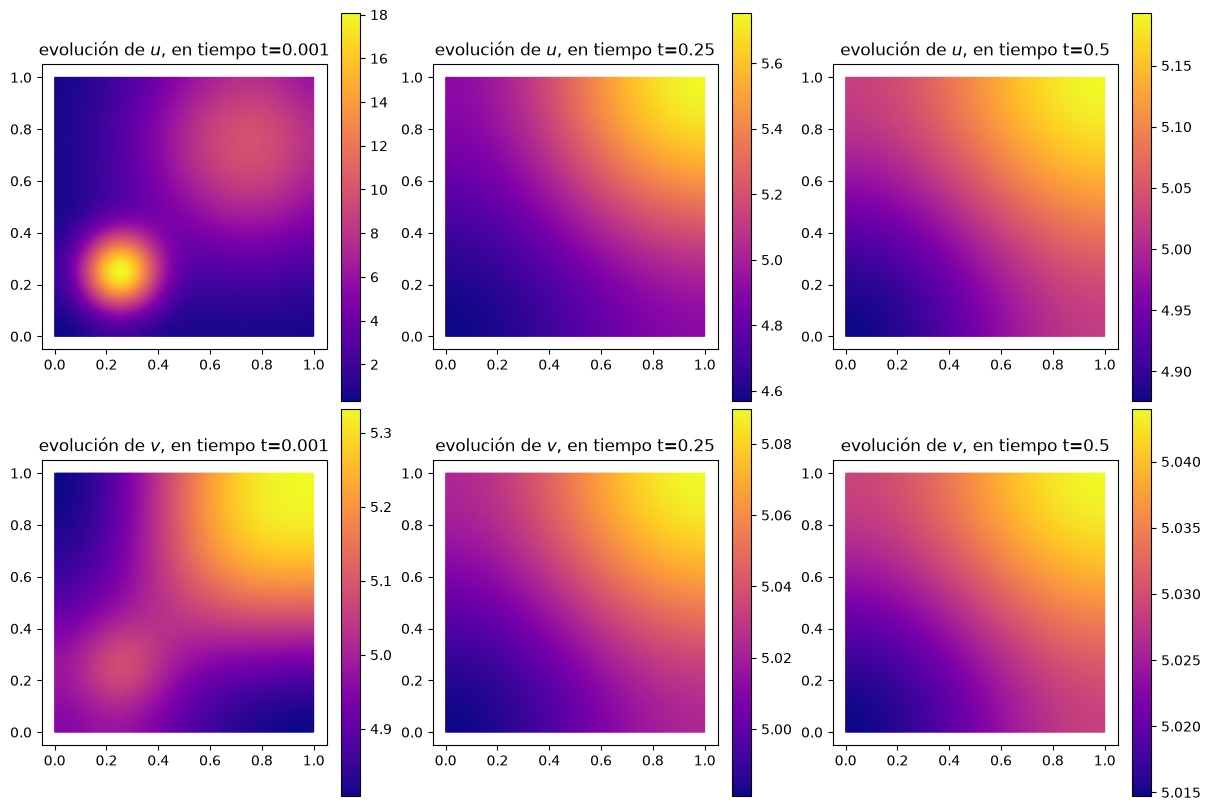

In [ ]:
fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 8),
    constrained_layout=True
)

for j, tiempo in enumerate(tiempos_guardar):

    ax = axs[0, j]
    im = ax.tripcolor(
        triang,
        soluciones_u[tiempo],
        shading="gouraud",
        cmap="plasma"
    )
    ax.set_title(f"evolución de $u$, en tiempo t={tiempo}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax)

    ax = axs[1, j]
    im = ax.tripcolor(
        triang,
        soluciones_v[tiempo],
        shading="gouraud",
        cmap="plasma"
    )
    ax.set_title(f"evolución de $v$, en tiempo t={tiempo}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax)

plt.show()

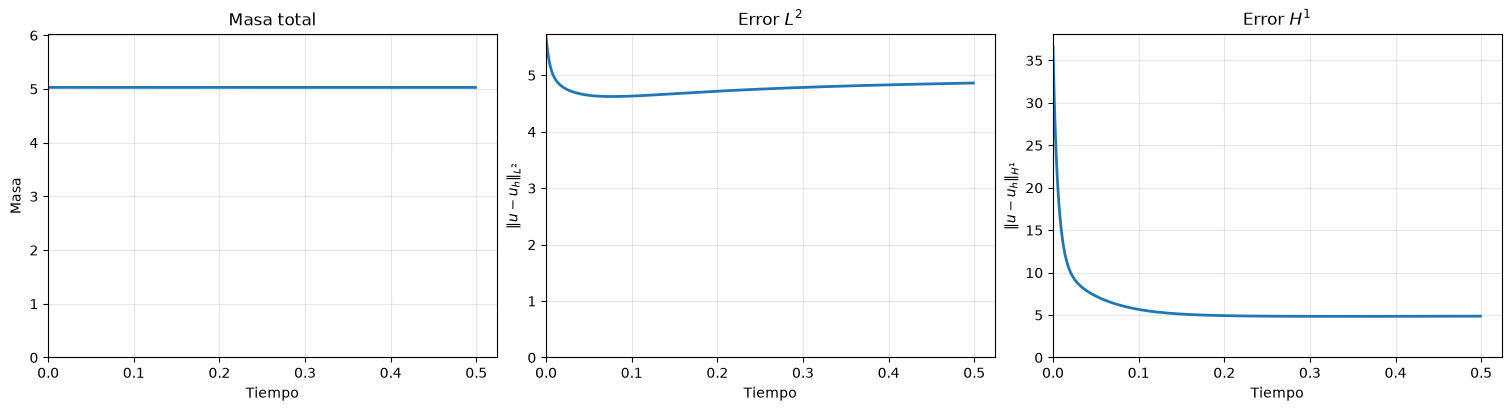

In [128]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    constrained_layout=True
)

# Masa
axs[0].plot(historial_tiempo, historial_masa, linewidth=2)
axs[0].set_title("Masa total")
axs[0].set_xlabel("Tiempo")
axs[0].set_ylabel("Masa")
axs[0].set_ylim(bottom=0, top=historial_masa[0] + 1)
axs[0].grid(True)

# Error L2
axs[1].plot(historial_tiempo, historial_L2, linewidth=2)
axs[1].set_title(r"Error $L^2$")
axs[1].set_xlabel("Tiempo")
axs[1].set_ylabel(r"$\|u-u_h\|_{L^2}$")
axs[1].set_ylim(bottom=0)
axs[1].grid(True)

# Error H1
axs[2].plot(historial_tiempo, historial_H1, linewidth=2)
axs[2].set_title(r"Error $H^1$")
axs[2].set_xlabel("Tiempo")
axs[2].set_ylabel(r"$\|u-u_h\|_{H^1}$")
axs[2].set_ylim(bottom=0)
axs[2].grid(True)

for ax in axs:
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

plt.show()